# Convección en una dimensión

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from matplotlib import pyplot as plt

## Parámetros

In [58]:
L  = 1.0           # longitud del sistema 1D
nx = 42            # nodos espaciales
dx = L / (nx-2)    # sí, quitamos dos nodos ...
x = np.linspace( 0 , L , num=nx )

T= 0.5            # tiempo total
nt = 100            # pasos temporales
dt = T / nt

c = 1              # velocidad de la onda

### ¡Número de Courant !

In [59]:
Co = c * dt / dx
Co

0.19999999999999998

### Condiciones iniciales

In [53]:
def chistera(L, x1, x2,nx) :
    u = np.zeros( nx )
    dx = L / (nx-2) 
    n1 = int(x1 / dx)
    n2 = int(x2 / dx)
    u[ n1 : n2 ] = 1
    return u

In [26]:
u0 = chistera(L, L/4, L/2,nx)

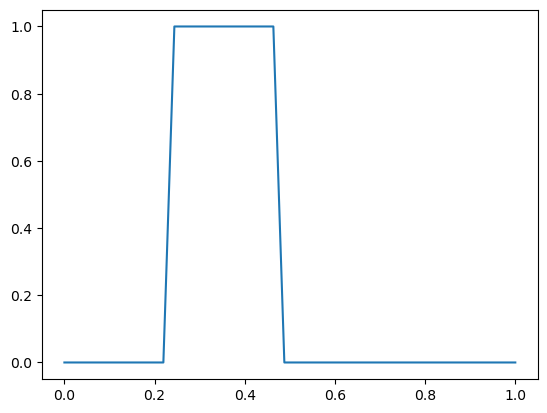

In [27]:
plt.plot( x , u0 )

In [34]:
def gaussiana(L, mean, sigma, nx) :
    u = np.zeros( nx )
    dx = L / (nx-2) 

    for i in range(0,nx):
        x = i * dx - mean
        u[i] = np.exp( - (x/sigma)**2 / 2)

    return u

In [35]:
u0 = gaussiana(L, L/4, L/10,nx)

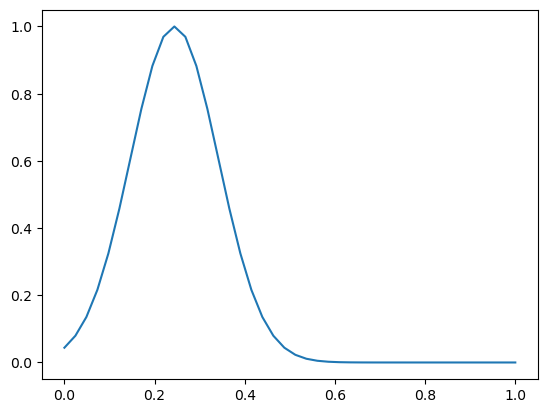

In [36]:
plt.plot( x , u0 )

### Un paso en el tiempo

Recordemos que queremos implementar $u_i^{n+1} = u_i^n - \mathrm{Co}(u_{i+1}^n-u_{i-1}^n)/2$

In [12]:
u = u0.copy()

In [13]:
_valor_izdo = u[0]

In [14]:
un = u.copy()         # distribución actual

i = 1
u[i] = un[i] - (Co / 2.0) * (un[i+1] - _valor_izdo )

for i in range( 2 , nx - 2 ):    # Ahora queda claro por qué hemos quitado los extremos !!
   u[i] = un[i] - (Co / 2.0) * (un[i+1] - un[i-1])


        

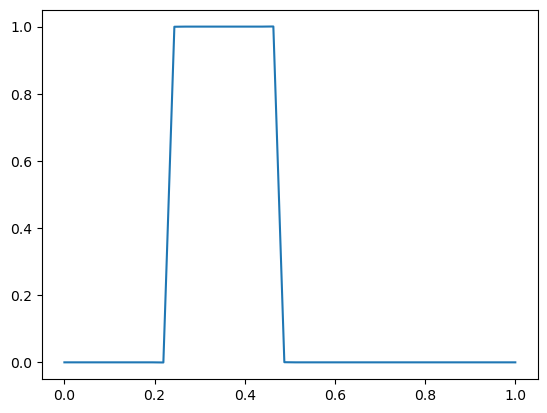

In [15]:
plt.plot(x,u)

### Tiempo completo

In [16]:
u0 = chistera(L, L/4, L/2,nx)

In [60]:
u0 = gaussiana(L, L/4, L/10,nx)

In [61]:
u = u0.copy()

In [62]:
for n in range(nt):
    un = u.copy()
    for i in range( 1 , nx - 1 ): 
        u[i] = un[i] - (Co / 2.0) * (un[i+1] - un[i-1])
    

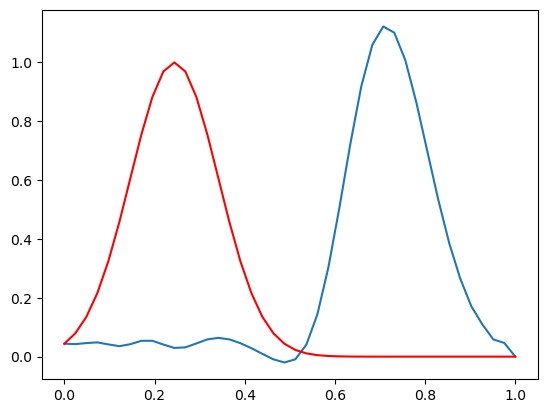

In [63]:
plt.plot(x , u , x , u0 , 'r')

### Formulaciones alternativas

¿Qué pasa si probamos el algoritmo "peor"?  $u_i^{n+1} = u_i^n - \mathrm{Co} (u_{i}^n-u_{i-1}^n)$

In [64]:
u = u0.copy()

In [65]:
for n in range(nt):
    un = u.copy()
    for i in range( 1 , nx ): 
        u[i] = un[i] - Co  * (un[i] - un[i-1])
        
        

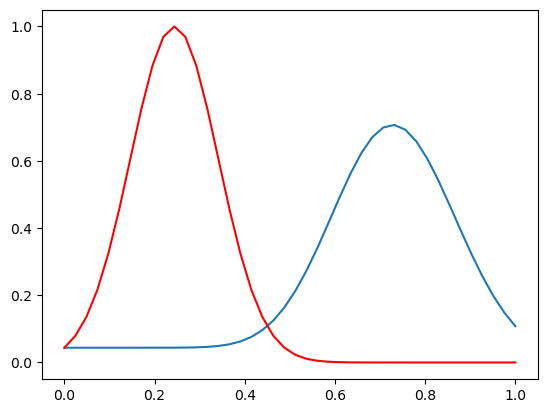

In [66]:
plt.plot(x , u , x , u0 , 'r')

### Reflexiones

* ¿Qué hemos hecho en los bordes? (condiciones de contorno)
* ¿Por qué los algoritmos difieren tantísimo?
* ¿Cuántos parámetros hay realmente? (Pista: 1)
